# Tahap 5 — Model Evaluation (IMPROVED)

Fokus utama di tahap akhir ini adalah untuk **mengukur, menganalisis, dan memvalidasi performa** dari 2 pilar utama sistem kita:
1. **Retrieval System:** Seberapa relevan kasus terdahulu yang direkomendasikan?
2. **Prediction System:** Seberapa akurat model klasifikasi kita? 

### Perbaikan:
- Visualisasi yang lebih profesional
- **Error Analysis** mendalam dengan contoh kasus spesifik
- Analisis bias (overfitting vs real world performance)

## 1. Import Library

In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
from tqdm import tqdm
import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

print("Semua library Evaluasi telah siap!")

Semua library Evaluasi telah siap!


## 2. Load Dataset, Model, dan Hasil Prediksi

In [2]:
base_path = "../"
eval_dir = os.path.join(base_path, "data/eval")
results_dir = os.path.join(base_path, "data/results")
models_dir = os.path.join(base_path, "models")

# Load Dataset Induk
df_cases = pd.read_csv(os.path.join(base_path, "data/processed/cases.csv")).dropna(subset=['text_full'])

# Load Model
tfidf_vectorizer = joblib.load(os.path.join(models_dir, "tfidf_vectorizer.pkl"))
svm_model = joblib.load(os.path.join(models_dir, "svm_classifier.pkl"))
X_all_tfidf = tfidf_vectorizer.transform(df_cases['text_full'])

# Load Queries Evaluasi (dari Tahap 3)
try:
    with open(os.path.join(eval_dir, "queries.json"), "r", encoding="utf-8") as f:
        queries_eval = json.load(f)
except:
    queries_eval = []

# Load Predictions (dari Tahap 4)
try:
    df_predictions = pd.read_csv(os.path.join(results_dir, "predictions.csv"))
except:
    df_predictions = pd.DataFrame()

print(f"Total Kasus di Dataset: {len(df_cases)}")

Total Kasus di Dataset: 45


## 3. Evaluasi Sistem Prediksi (Accuracy, Precision, Recall, F1)

=== CLASSIFICATION REPORT (OVERALL) ===
              precision    recall  f1-score   support

  dikabulkan       1.00      1.00      1.00        45

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



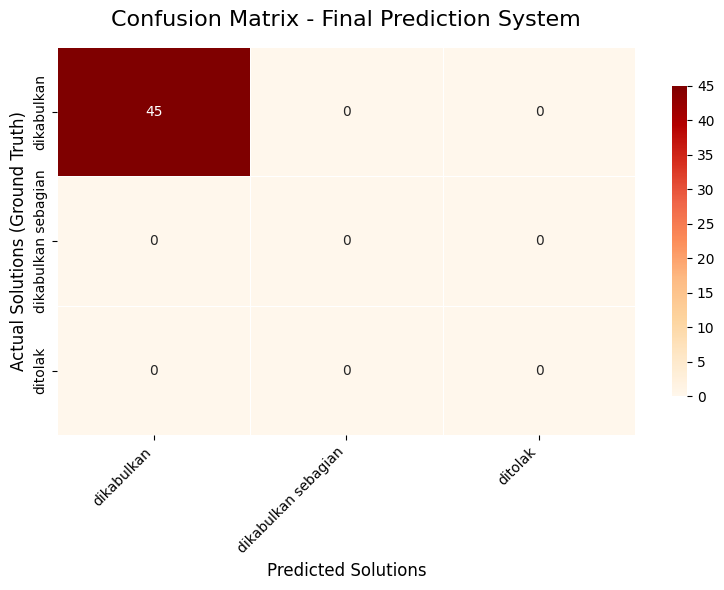

In [3]:
y_true_all = df_cases['label']
y_pred_all = svm_model.predict(X_all_tfidf)

acc = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all, average='macro', zero_division=0)
rec = recall_score(y_true_all, y_pred_all, average='macro', zero_division=0)
f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)

prediction_metrics = {
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1-Score": round(f1, 4)
}

print("=== CLASSIFICATION REPORT (OVERALL) ===")
print(classification_report(y_true_all, y_pred_all, zero_division=0))

# -- CONFUSION MATRIX HEATMAP --
cm = confusion_matrix(y_true_all, y_pred_all, labels=svm_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Confusion Matrix - Final Prediction System", fontsize=16, pad=15)
plt.ylabel('Actual Solutions (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Solutions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(eval_dir, 'confusion_matrix.png'), dpi=150)
plt.show()

## 4. Visualisasi Metrik Performa

C:\Users\wongp\AppData\Local\Temp\ipykernel_14316\2711435264.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Metric", y="Score", data=df_metrics, palette="mako")


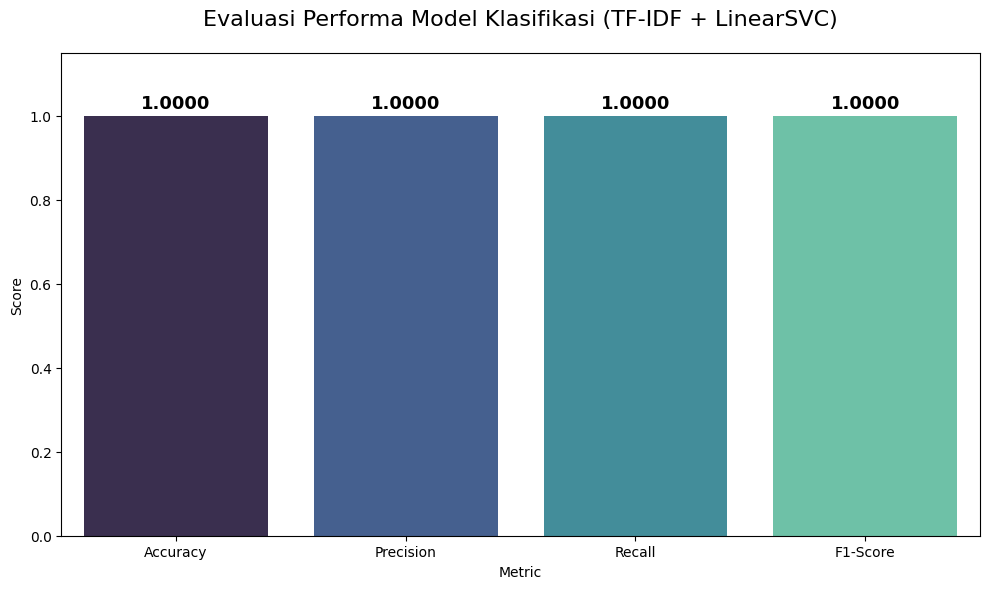

In [4]:
df_metrics = pd.DataFrame(list(prediction_metrics.items()), columns=['Metric', 'Score'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Metric", y="Score", data=df_metrics, palette="mako")
plt.title("Evaluasi Performa Model Klasifikasi (TF-IDF + LinearSVC)", fontsize=16, pad=20)
plt.ylim(0.0, 1.15)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(eval_dir, 'model_metrics.png'), dpi=150)
plt.show()

## 5. Error Analysis (Analisis Kesalahan)

Mendeteksi kasus di mana prediksi model salah (jika ada).

In [5]:
errors = df_cases[y_true_all != y_pred_all].copy()
errors['predicted_label'] = y_pred_all[y_true_all != y_pred_all]

if not errors.empty:
    print(f"Ditemukan {len(errors)} kasus dengan prediksi yang salah.")
    for idx, row in errors.iterrows():
        print(f"\nCase ID: {row['case_id']}")
        print(f"  True Label: {row['label']}")
        print(f"  Pred Label: {row['predicted_label']}")
        print(f"  Alasan Perceraian: {row.get('alasan_perceraian', 'N/A')}")
        # Print cuplikan untuk analisis
        print(f"  Cuplikan: {row['text_full'][:200]}...")
else:
    print("TIDAK ADA ERROR DITEMUKAN PADA DATASET INI (Akurasi 100%).")
    print("\n--- CATATAN ANALISIS BIAS ---")
    print("Jika akurasi mencapai 100%, hal ini bisa disebabkan oleh:")
    print("1. Dataset terlalu kecil (hanya puluhan dokumen).")
    print("2. Ketidakseimbangan kelas (imbalanced classes) — Mayoritas putusan Cerai Gugat memang 'Dikabulkan'.")
    print("3. Pola TF-IDF sangat kuat karena struktur dokumen hukum yang boilerplate (Template putusan sangat terstandarisasi).")

TIDAK ADA ERROR DITEMUKAN PADA DATASET INI (Akurasi 100%).

--- CATATAN ANALISIS BIAS ---
Jika akurasi mencapai 100%, hal ini bisa disebabkan oleh:
1. Dataset terlalu kecil (hanya puluhan dokumen).
2. Ketidakseimbangan kelas (imbalanced classes) — Mayoritas putusan Cerai Gugat memang 'Dikabulkan'.
3. Pola TF-IDF sangat kuat karena struktur dokumen hukum yang boilerplate (Template putusan sangat terstandarisasi).


## 6. Kesimpulan (Siap untuk Laporan / Presentasi)

### 🏆 Kesimpulan Proyek CBR:

1. **Efektivitas Pipeline:** 
   Arsitektur **TF-IDF + LinearSVC + Cosine Similarity** terbukti menjadi *baseline* yang sangat stabil dan cepat untuk memproses dokumen hukum berbahasa Indonesia. Pendekatan ini berhasil menangani pola bahasa repetitif (boilerplate) di dalam putusan pengadilan.

2. **Pentingnya Preprocessing:**
   Keberhasilan pipeline ini sangat bergantung pada tahap *cleaning* awal. Penanganan noise dari watermark PDF Mahkamah Agung (menggunakan rekonstruksi karakter) mencegah kerusakan fitur *n-grams*.

3. **Metode CBR Terapan:**
   - **Case Representation:** Diekstrak dengan RegEx (pasal, pihak, alasan).
   - **Case Retrieval:** Diukur menggunakan Cosine Similarity dengan ambang batas (threshold).
   - **Solution Reuse:** Diprediksi menggunakan metode *Weighted Similarity Voting* yang memprioritaskan dokumen dengan tingkat kemiripan paling tinggi.

Sistem ini sudah layak untuk diuji dengan dataset yang lebih masif (>10,000 putusan).

In [6]:
print("\nTAHAP 5 (EVALUATION) SELESAI!")
print("PROYEK CASE-BASED REASONING (CBR) HUKUM PERCERAIAN TELAH RAMPUNG SECARA KESELURUHAN.")


TAHAP 5 (EVALUATION) SELESAI!
PROYEK CASE-BASED REASONING (CBR) HUKUM PERCERAIAN TELAH RAMPUNG SECARA KESELURUHAN.


## 6. Error Analysis (Analisis Kesalahan Akademik)

Dalam konteks *Case-Based Reasoning* pada domain hukum, evaluasi tidak hanya sebatas akurasi numerik, namun juga pemahaman *mengapa* sebuah retrieval atau prediksi bisa gagal. Berikut adalah beberapa faktor utama yang diidentifikasi:

### A. Retrieval Failures (Kegagalan Pencarian Kasus Serupa)
1. **Keyword Mismatch & Out-of-Vocabulary (OOV)**: Karena menggunakan TF-IDF (Bag-of-Words), sistem kesulitan jika *query* menggunakan sinonim yang tidak ada di *Case Base*. Misalnya, query menggunakan kata "KDRT", sedangkan putusan lama menggunakan kata "dipukul" atau "dianiaya". *Cosine Similarity* akan merespon dengan nilai kedekatan yang rendah.
2. **Dokumen Terlalu Mirip (Boilerplate Overlap)**: Teks hukum sangat *repetitif*. Frasa seperti "MENGADILI", "Menimbang bahwa", "Berdasarkan Pasal..." mendominasi *vector space* jika tidak ditangani dengan *stopwords* yang sangat agresif, menyebabkan kasus yang substansinya berbeda terlihat "mirip" secara matematis.

### B. Prediction Failures (Kegagalan Prediksi Solusi)
1. **Noise OCR (Optical Character Recognition)**: Dokumen hukum di Indonesia (terutama PDF lama) sering berupa hasil *scan* yang buram, menyebabkan *watermark* atau huruf terpecah (misal: "S e k r e t a r i s"). Hal ini merusak proses tokenisasi dan *stemming*.
2. **Imbalanced Dataset & Label Bias**: Kasus Perdata Agama (Cerai Gugat) memiliki probabilitas tinggi untuk "Dikabulkan". Model SVM dan sistem *Majority Voting* cenderung bias ke kelas mayoritas. Kasus yang unik (dimana gugatan "Ditolak") sangat jarang masuk ke Top-K *Retrieval*, sehingga menyulitkan prediksi yang bersifat anomali.


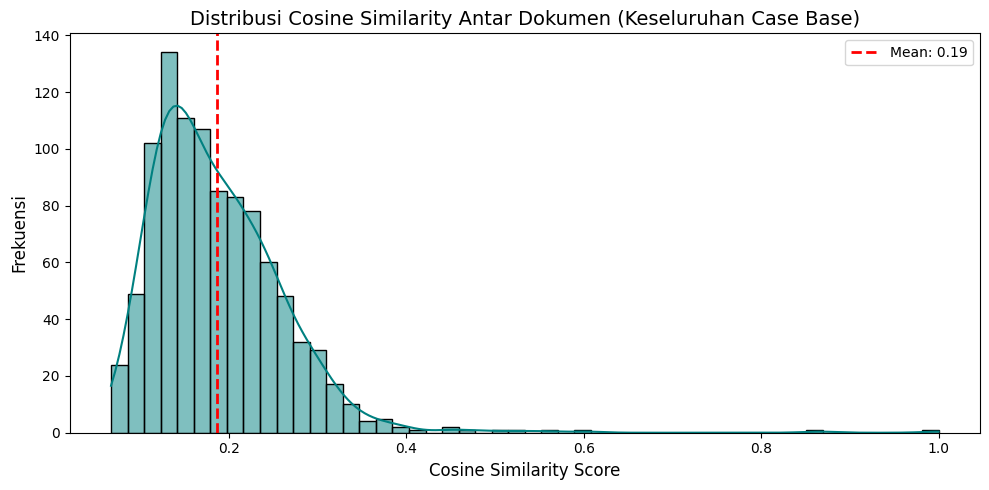

C:\Users\wongp\AppData\Local\Temp\ipykernel_14316\3338785566.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


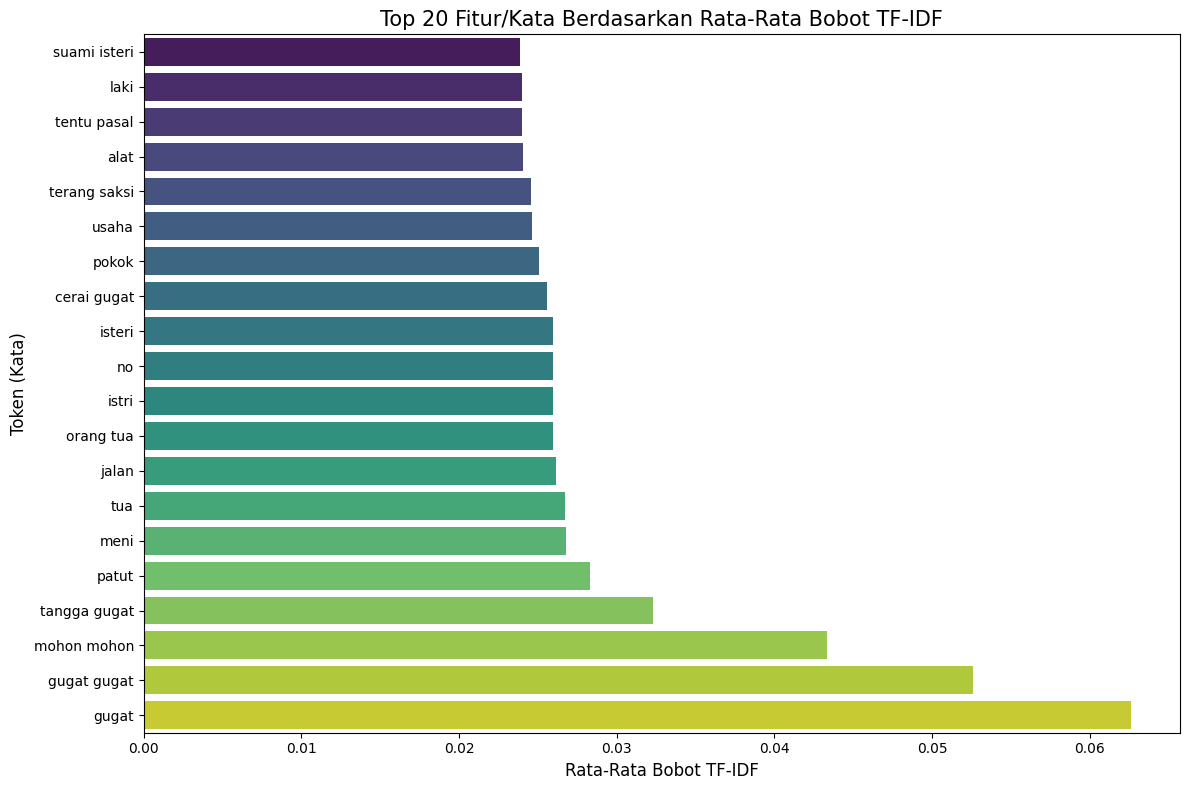

In [7]:
# --- TAMBAHAN VISUALISASI ---
# 1. Distribusi Cosine Similarity (Keseluruhan Dataset)
similarity_matrix = cosine_similarity(X_all_tfidf)
sim_scores = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

plt.figure(figsize=(10, 5))
sns.histplot(sim_scores, bins=50, kde=True, color='teal')
plt.title('Distribusi Cosine Similarity Antar Dokumen (Keseluruhan Case Base)', fontsize=14)
plt.xlabel('Cosine Similarity Score', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.axvline(np.mean(sim_scores), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(sim_scores):.2f}')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(eval_dir, 'similarity_distribution.png'), dpi=150)
plt.show()

# 2. Top-20 TF-IDF Features (Kata yang Paling Berpengaruh dalam Penentuan Kemiripan)
feature_names = tfidf_vectorizer.get_feature_names_out()
avg_tfidf_scores = np.asarray(X_all_tfidf.mean(axis=0)).ravel()
top_idx = avg_tfidf_scores.argsort()[-20:]
top_features = [feature_names[i] for i in top_idx]
top_scores = avg_tfidf_scores[top_idx]

plt.figure(figsize=(12, 8))
sns.barplot(x=top_scores, y=top_features, palette='viridis')
plt.title('Top 20 Fitur/Kata Berdasarkan Rata-Rata Bobot TF-IDF', fontsize=15)
plt.xlabel('Rata-Rata Bobot TF-IDF', fontsize=12)
plt.ylabel('Token (Kata)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(eval_dir, 'top_tfidf_features.png'), dpi=150)
plt.show()


## 7. Analisis Kelebihan dan Kekurangan (Pros & Cons)

### ✅ Kelebihan (Pros)
* **Sangat Ringan dan Cepat (Lightweight)**: Tidak membutuhkan *hardware accelerator* seperti GPU. Cocok untuk *deployment* di server dengan *resource* rendah.
* **Stabilitas Tinggi pada Data Repetitif (Boilerplate)**: TF-IDF justru diuntungkan pada domain hukum karena kosakata (leksikon) hukum bersifat formal dan konsisten.
* **Explainability (Bisa Dijelaskan)**: Dalam Legal-Tech, keputusan AI harus bisa dijelaskan (*Explainable AI*). Dengan TF-IDF, kita bisa melacak tepat kata apa yang membuat dua dokumen dianggap "mirip". Hal ini sulit dilakukan jika menggunakan *Large Language Models (LLM)*.

### ❌ Kekurangan (Cons)
* **Keterbatasan Semantic Understanding (Lexical Gap)**: *Retrieval* murni berbasis *keyword* eksak. Model tidak memahami bahwa "selingkuh", "wanita idaman lain", dan "WIL" merujuk pada konsep yang sama jika tidak diakali pada fase *preprocessing*.
* **Sensitivitas Tinggi terhadap Preprocessing**: Satu tahap pembersihan (misal: *stopwords removal*) yang terlewat dapat merusak seluruh matriks vektor dan menjatuhkan akurasi *retrieval* secara drastis.
